# 04 · Regression analysis and robustness checks

Interactive counterpart to `scripts/03_fit.py`: the same models, one per cell, with full statsmodels output.
Reads `data/processed/panel.csv`; writes nothing (the script is the pipeline of record).

**Question.** How much of cross-country variation in MDD-W (% women 15–49 achieving minimum dietary diversity)
is explained by PUA (% of population unable to afford a healthy diet), and is the residual robust to reasonable
alternative specifications?

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm, statsmodels.formula.api as smf, scipy.stats as st
pd.set_option("display.max_rows", 200, "display.width", 180, "display.precision", 3)
SEED = 42; rng = np.random.default_rng(SEED)

p = pd.read_csv("../data/processed/panel.csv")
p["log_gdp"] = np.log(p.gdp_pcap_ppp)
n = len(p); print(n, "countries")
p[["mddw", "pua", "cohd", "gdp_pcap_ppp", "log_gdp"]].describe().round(2)

66 countries


,mddw,pua,cohd,gdp_pcap_ppp,log_gdp
count,66.00,66.00,66.00,66.00,66.00
mean,59.36,47.05,4.12,11585.38,8.92
std,23.64,26.96,0.88,12611.65,0.97
min,17.20,1.10,2.59,1033.01,6.94
25%,39.51,23.32,3.55,3475.26,8.15
50%,58.79,49.60,3.99,7941.10,8.98
75%,79.33,68.60,4.52,15880.18,9.67
max,91.20,92.10,6.74,85383.36,11.35


In [2]:
# Pairwise correlations among the candidate predictors
p[["mddw", "pua", "log_gdp", "cohd"]].corr().round(3)

,mddw,pua,log_gdp,cohd
mddw,1.000,-0.807,0.784,0.019
pua,-0.807,1.000,-0.780,-0.025
log_gdp,0.784,-0.780,1.000,0.182
cohd,0.019,-0.025,0.182,1.000


## 1. Headline model: OLS `mddw ~ pua`

HC3 (heteroskedasticity-robust) standard errors — the residual spread is visibly larger at mid-range PUA.

In [3]:
ols = smf.ols("mddw ~ pua", data=p).fit(cov_type="HC3")
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                   mddw   R-squared:                       0.652
Model:                            OLS   Adj. R-squared:                  0.647
Method:                 Least Squares   F-statistic:                     158.9
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           5.36e-19
Time:                        08:19:26   Log-Likelihood:                -267.07
No. Observations:                  66   AIC:                             538.1
Df Residuals:                      64   BIC:                             542.5
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     92.6693      2.866     32.335      0.0

**Reading it:** intercept ≈ predicted MDD-W when nobody is priced out; slope = MDD-W points lost per point of unaffordability.

## 2. Bootstrap uncertainty (resample countries)

The HC3 SE assumes the linear model is right; a country-level bootstrap gives a model-agnostic CI for the slope and — more usefully — for R², which has no analytic SE.

slope 95% CI: [-0.818 -0.595]
R²    95% CI: [0.501 0.782]


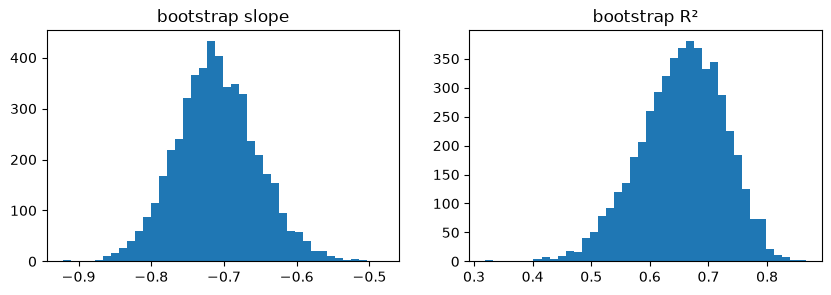

In [4]:
N_BOOT = 5000
boot = np.empty((N_BOOT, 2))
for i in range(N_BOOT):
    s = p.sample(n, replace=True, random_state=rng.integers(1 << 31))
    f = smf.ols("mddw ~ pua", data=s).fit()
    boot[i] = f.params["pua"], f.rsquared
print("slope 95% CI:", np.percentile(boot[:, 0], [2.5, 97.5]).round(3))
print("R²    95% CI:", np.percentile(boot[:, 1], [2.5, 97.5]).round(3))
fig, ax = plt.subplots(1, 2, figsize=(10, 3)); ax[0].hist(boot[:, 0], 40); ax[0].set_title("bootstrap slope"); ax[1].hist(boot[:, 1], 40); ax[1].set_title("bootstrap R²");

## 3. Diagnostics

Residuals vs fitted (nonlinearity / heteroskedasticity), Q–Q of studentized residuals (tails), Cook's D (influence).

Breusch-Pagan p = 0.351 | Shapiro-Wilk p = 0.57 | RESET(quadratic) p = 0.107


,country,pua,mddw,resid,std_resid,cooks_d,mddw_source_group
27,Indonesia,69.7,86.13,42.81,3.32,0.13,GDQP
49,Malaysia,1.9,62.94,-28.38,-2.14,0.13,GDQP


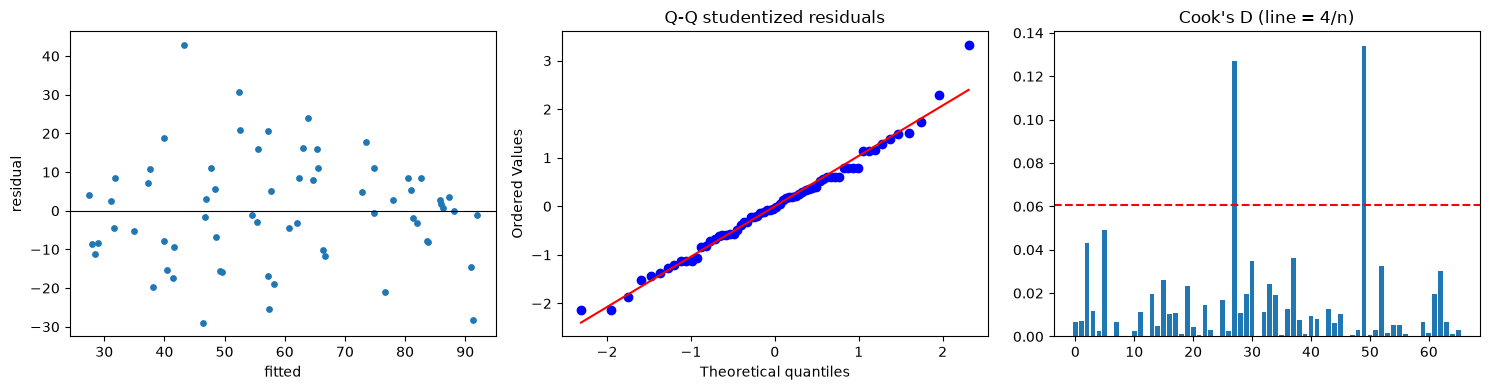

In [5]:
infl = ols.get_influence()
p["fitted"], p["resid"] = ols.fittedvalues, ols.resid
p["std_resid"], p["cooks_d"] = infl.resid_studentized_external, infl.cooks_distance[0]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].scatter(p.fitted, p.resid, s=15); ax[0].axhline(0, c="k", lw=.8); ax[0].set(xlabel="fitted", ylabel="residual")
st.probplot(p.std_resid, plot=ax[1]); ax[1].set_title("Q-Q studentized residuals")
ax[2].bar(range(n), p.cooks_d); ax[2].axhline(4 / n, c="r", ls="--"); ax[2].set_title("Cook's D (line = 4/n)")
plt.tight_layout()
print("Breusch-Pagan p =", round(sm.stats.diagnostic.het_breuschpagan(ols.resid, ols.model.exog)[1], 3),
      "| Shapiro-Wilk p =", round(st.shapiro(p.std_resid).pvalue, 3),
      "| RESET(quadratic) p =", round(sm.stats.diagnostic.linear_reset(smf.ols("mddw ~ pua", data=p).fit(), power=2, use_f=True).pvalue, 3))
p[p.cooks_d > 4 / n][["country", "pua", "mddw", "resid", "std_resid", "cooks_d", "mddw_source_group"]].round(2)

RESET tests whether adding PUA² improves fit — a check that a straight line is adequate for two bounded percentages.

## 4. Bounded outcome: fractional logit

MDD-W is a share in (0,1). A quasi-binomial GLM with a logit link respects the bounds. We compare its residuals to the OLS residuals — if they rank countries the same way, OLS is fine as the headline.

In [6]:
frac = smf.glm("I(mddw/100) ~ pua", data=p, family=sm.families.Binomial()).fit(cov_type="HC3")
print(frac.summary().tables[1])
resid_frac = p.mddw - 100 * frac.predict(p)
print("Spearman(resid_frac, resid_ols) =", round(pd.Series(resid_frac).corr(p.resid, method="spearman"), 3))
# average marginal effect of PUA on the % scale, for comparability with the OLS slope
print("AME of pua (pct points):", round(float((frac.params["pua"] * frac.predict(p) * (1 - frac.predict(p)) * 100).mean()), 3))

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.0005      0.164     12.225      0.000       1.680       2.321
pua           -0.0329      0.003    -11.415      0.000      -0.039      -0.027
Spearman(resid_frac, resid_ols) = 0.993
AME of pua (pct points): -0.675


## 5. Is affordability just income?

Three regressions: income alone; affordability + income; and the correlation of the headline residual with income.

In [7]:
m_gdp  = smf.ols("mddw ~ log_gdp", data=p).fit(cov_type="HC3")
m_both = smf.ols("mddw ~ pua + log_gdp", data=p).fit(cov_type="HC3")
print(m_both.summary().tables[1])
print(f"R²: gdp only {m_gdp.rsquared:.3f} | pua only {ols.rsquared:.3f} | both {m_both.rsquared:.3f}")
print("corr(headline residual, log gdp) =", round(np.corrcoef(p.resid, p.log_gdp)[0, 1], 3))
# variance inflation between the two predictors
r_xx = np.corrcoef(p.pua, p.log_gdp)[0, 1]; print("VIF =", round(1 / (1 - r_xx**2), 2))

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.8752     32.083     -0.183      0.855     -68.757      57.007
pua           -0.4387      0.109     -4.017      0.000      -0.653      -0.225
log_gdp        9.6321      3.115      3.092      0.002       3.527      15.738
R²: gdp only 0.615 | pua only 0.652 | both 0.713
corr(headline residual, log gdp) = 0.261
VIF = 2.56


**Interpretation.** If PUA's coefficient shrinks toward zero once log GDP is in, "affordability" is a proxy for income. If it keeps most of its size and significance, affordability carries information beyond income.

## 6. Survey-source confounding

MDD-W comes from the Global Diet Quality Project (Gallup), DHS, or one-off national surveys. Where a country has both, GDQP runs 20–30 points above DHS. Two checks: (a) source dummies; (b) GDQP-only subsample.

In [8]:
src = smf.ols("mddw ~ pua + C(mddw_source_group, Treatment('GDQP'))", data=p).fit(cov_type="HC3")
print(src.summary().tables[1])
resid_src = src.resid
print("Spearman(resid_src_adj, resid_ols) =", round(resid_src.corr(p.resid, method="spearman"), 3))
gd = p[p.mddw_source_group == "GDQP"]
gdqp = smf.ols("mddw ~ pua", data=gd).fit(cov_type="HC3")
print(f"GDQP only: n={len(gd)}, slope={gdqp.params['pua']:.3f} (se {gdqp.bse['pua']:.3f}), R²={gdqp.rsquared:.3f}")

                                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
Intercept                                           92.1372      2.615     35.239      0.000      87.013      97.262
C(mddw_source_group, Treatment('GDQP'))[T.DHS]     -12.8413      4.124     -3.114      0.002     -20.924      -4.758
C(mddw_source_group, Treatment('GDQP'))[T.Other]   -11.0495      6.985     -1.582      0.114     -24.741       2.642
pua                                                 -0.6174      0.062     -9.902      0.000      -0.740      -0.495
Spearman(resid_src_adj, resid_ols) = 0.918
GDQP only: n=46, slope=-0.586 (se 0.084), R²=0.507


In [9]:
# Which countries move most once source is adjusted?
cmp = pd.DataFrame({"country": p.country, "source": p.mddw_source_group, "resid": p.resid, "resid_src_adj": resid_src})
cmp["rank_shift"] = cmp.resid_src_adj.rank(ascending=False) - cmp.resid.rank(ascending=False)
cmp.reindex(cmp.rank_shift.abs().sort_values(ascending=False).index).head(12).round(1)

,country,source,resid,resid_src_adj,rank_shift
30,Jordan,DHS,-14.6,-1.4,-18.0
35,Lebanon,Other,-4.5,3.0,-17.0
47,Mauritius,Other,2.7,12.4,-16.0
56,Senegal,DHS,5.1,14.0,-14.0
50,Niger,GDQP,2.4,-4.9,14.0
65,Zambia,DHS,-4.6,1.0,-13.0
53,Pakistan,GDQP,5.6,0.5,13.0
51,Nigeria,DHS,-5.3,0.7,-13.0
40,Madagascar,GDQP,8.4,1.2,13.0
14,Congo,GDQP,7.2,0.6,12.0


In [10]:
# Does the PUA slope differ by source? (interaction)
inter = smf.ols("mddw ~ pua * C(mddw_source_group, Treatment('GDQP'))", data=p).fit(cov_type="HC3")
inter.summary().tables[1]

,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,90.8827,3.141,28.932,0.000,84.726,97.040
"C(mddw_source_group, Treatment('GDQP'))[T.DHS]",-13.9168,6.843,-2.034,0.042,-27.330,-0.504
"C(mddw_source_group, Treatment('GDQP'))[T.Other]",10.2242,9.694,1.055,0.292,-8.776,29.225
pua,-0.5858,0.084,-6.983,0.000,-0.750,-0.421
"pua:C(mddw_source_group, Treatment('GDQP'))[T.DHS]",0.0030,0.116,0.026,0.980,-0.224,0.230
"pua:C(mddw_source_group, Treatment('GDQP'))[T.Other]",-0.3849,0.210,-1.831,0.067,-0.797,0.027


## 7. Year-matching sensitivity

Headline uses CoAHD in the MDD-W survey year. Alternative: latest available CoAHD (2025) for everyone.

In [11]:
lat = smf.ols("mddw ~ pua_latest", data=p).fit(cov_type="HC3")
print(f"slope={lat.params['pua_latest']:.3f} (se {lat.bse['pua_latest']:.3f}), R²={lat.rsquared:.3f}")
print("Spearman(resid_latest, resid_ols) =", round(lat.resid.corr(p.resid, method="spearman"), 3))
print("PUA change (latest - matched):"); (p.pua_latest - p.pua).describe().round(2)

slope=-0.708 (se 0.053), R²=0.680
Spearman(resid_latest, resid_ols) = 0.979
PUA change (latest - matched):


count    66.00
mean     -2.04
std       4.10
min     -18.50
25%      -3.47
50%      -1.10
75%       0.15
max      10.40
dtype: float64

## 8. Influence: drop Cook's D > 4/n, and jackknife the slope

In [12]:
keep = p[p.cooks_d <= 4 / n]
drop = smf.ols("mddw ~ pua", data=keep).fit(cov_type="HC3")
print(f"dropped {n - len(keep)}: slope={drop.params['pua']:.3f}, R²={drop.rsquared:.3f}")
# leave-one-out slopes: which single country moves the slope most?
loo = pd.Series({p.country[i]: smf.ols("mddw ~ pua", data=p.drop(i)).fit().params["pua"] for i in p.index})
(loo - ols.params["pua"]).abs().sort_values(ascending=False).head(8).round(4)

dropped 2: slope=-0.758, R²=0.722


Malaysia                            0.029
Indonesia                           0.021
Jordan                              0.015
Lesotho                             0.013
Burkina Faso                        0.011
Uganda                              0.011
Nepal                               0.011
Democratic Republic of the Congo    0.011
dtype: float64

## 9. Alternative predictor: cost of a healthy diet (PPP$/day) instead of unaffordability

In [13]:
m_cost = smf.ols("mddw ~ cohd", data=p).fit(cov_type="HC3")
m_cost2 = smf.ols("mddw ~ pua + cohd", data=p).fit(cov_type="HC3")
print(f"cost only: coef={m_cost.params['cohd']:.2f}, R²={m_cost.rsquared:.3f}")
print(m_cost2.summary().tables[1])

cost only: coef=0.50, R²=0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     92.8473      7.099     13.079      0.000      78.934     106.761
pua           -0.7080      0.057    -12.506      0.000      -0.819      -0.597
cohd          -0.0428      1.652     -0.026      0.979      -3.280       3.194


Cost level and affordability are different things: a diet can be cheap in PPP terms and still unaffordable if incomes are low. This checks which one carries the signal.

## 10. Summary table

In [14]:
rows = [("OLS mddw ~ pua (headline)", ols, "pua"), ("Fractional logit (logit scale)", frac, "pua"),
        ("OLS mddw ~ log_gdp", m_gdp, "log_gdp"), ("OLS mddw ~ pua + log_gdp  [pua]", m_both, "pua"),
        ("OLS mddw ~ pua + log_gdp  [log_gdp]", m_both, "log_gdp"), ("OLS + source dummies  [pua]", src, "pua"),
        ("GDQP-sourced only", gdqp, "pua"), ("Latest-year PUA", lat, "pua_latest"), ("Drop Cook's D > 4/n", drop, "pua"),
        ("OLS mddw ~ cohd", m_cost, "cohd"), ("OLS mddw ~ pua + cohd  [pua]", m_cost2, "pua")]
pd.DataFrame([{"model": m, "n": int(f.nobs), "coef": f.params[t], "se": f.bse[t], "p": f.pvalues[t],
               "r2": getattr(f, "rsquared", np.nan)} for m, f, t in rows]).round(3)

,model,n,coef,se,p,r2
0,OLS mddw ~ pua (headline),66,-0.708,0.056,0.000,0.652
1,Fractional logit (logit scale),66,-0.033,0.003,0.000,NaN
2,OLS mddw ~ log_gdp,66,19.187,1.726,0.000,0.615
3,OLS mddw ~ pua + log_gdp [pua],66,-0.439,0.109,0.000,0.713
4,OLS mddw ~ pua + log_gdp [log_gdp],66,9.632,3.115,0.002,0.713
5,OLS + source dummies [pua],66,-0.617,0.062,0.000,0.700
6,GDQP-sourced only,46,-0.586,0.084,0.000,0.507
7,Latest-year PUA,66,-0.708,0.053,0.000,0.680
8,Drop Cook's D > 4/n,64,-0.758,0.046,0.000,0.722
9,OLS mddw ~ cohd,66,0.505,3.118,0.871,0.000


## 11. Region fixed effects — a within-region benchmark

Does a country look unusual relative to the *global* affordability line, or relative to countries in the same broad region? If the PUA slope shrinks a lot with region FE, part of the "affordability" signal is regional structure.

In [15]:
reg = smf.ols("mddw ~ pua + C(region)", data=p).fit(cov_type="HC3")
print(reg.summary().tables[1])
print(f"R² {reg.rsquared:.3f} | PUA slope {reg.params['pua']:.3f} | Spearman(resid_regionFE, resid_ols) = {reg.resid.corr(p.resid, method='spearman'):.3f}")
pd.DataFrame({"country": p.country, "region": p.region, "resid_global": p.resid, "resid_within_region": reg.resid}).round(1).sort_values("resid_within_region").head(10)

                                                                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------
Intercept                                                         87.7200      8.924      9.829      0.000      70.229     105.212
C(region)[T.Europe & Central Asia]                                 4.0030      9.008      0.444      0.657     -13.652      21.658
C(region)[T.Latin America & Caribbean]                             4.6536      8.835      0.527      0.598     -12.662      21.970
C(region)[T.Middle East, North Africa, Afghanistan & Pakistan]    -0.4834      9.333     -0.052      0.959     -18.775      17.809
C(region)[T.South Asia]                                          -17.7121     11.715     -1.512      0.131     -40.672       5.248
C(region)[T.Sub-Saharan Africa]                                  -21.9677     10.54

,country,region,resid_global,resid_within_region
49,Malaysia,East Asia & Pacific,-28.4,-24.0
5,Burkina Faso,Sub-Saharan Africa,-28.9,-23.0
44,Mongolia,East Asia & Pacific,-11.7,-18.5
37,Lesotho,Sub-Saharan Africa,-19.8,-17.6
15,Comoros,Sub-Saharan Africa,-25.5,-14.5
19,Ethiopia,Sub-Saharan Africa,-17.4,-13.7
35,Lebanon,"Middle East, North Africa, Afghanistan & Pakistan",-4.5,-13.6
13,Democratic Republic of the Congo,Sub-Saharan Africa,-11.2,-13.4
61,United Republic of Tanzania,Sub-Saharan Africa,-15.4,-12.2
3,Burundi,Sub-Saharan Africa,-8.5,-11.0


## 12. Restricted cubic spline — is the straight line adequate?

   df_resid        ssr  df_diff  ss_diff      F  Pr(>F)
0      64.0  12644.002      0.0      NaN    NaN     NaN
1      62.0  11959.403      2.0  684.599  1.775   0.178


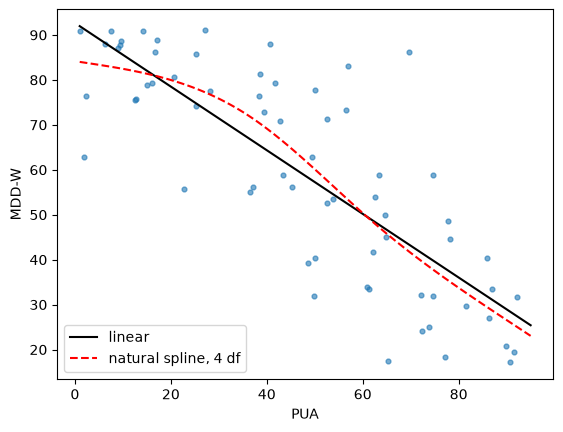

In [16]:
spl = smf.ols("mddw ~ cr(pua, df=4)", data=p).fit()
lin = smf.ols("mddw ~ pua", data=p).fit()
print(sm.stats.anova_lm(lin, spl))
xs = pd.DataFrame({"pua": np.linspace(1, 95, 100)})
plt.scatter(p.pua, p.mddw, s=12, alpha=.6); plt.plot(xs.pua, lin.predict(xs), "k-", label="linear"); plt.plot(xs.pua, spl.predict(xs), "r--", label="natural spline, 4 df"); plt.legend(); plt.xlabel("PUA"); plt.ylabel("MDD-W");

## 13. DHS/national-only, precision-weighted WLS, and survey coverage flags

`mddw_se` is an *approximate* binomial SE from an assumed effective sample (GDQP ≈ 0.45·N/deff ≈ 300; DHS 10k; other 2k). It is a crude weight, not a published CI. Flags come from `reference/mddw_survey_coverage.csv` (Gallup DQQ collection details).

In [17]:
nat = p[p.mddw_source_group != "GDQP"]
m_nat = smf.ols("mddw ~ pua", data=nat).fit(cov_type="HC3")
print(f"DHS/national only: n={len(nat)}, slope={m_nat.params['pua']:.3f} (se {m_nat.bse['pua']:.3f}), R²={m_nat.rsquared:.3f}")
wls = smf.wls("mddw ~ pua", data=p, weights=1 / p.mddw_se**2).fit(cov_type="HC3")
print(f"precision-weighted WLS: slope={wls.params['pua']:.3f} (se {wls.bse['pua']:.3f}), R²={wls.rsquared:.3f}, Spearman vs OLS resid = {wls.resid.corr(p.resid, method='spearman'):.3f}")
p["any_flag"] = p.flag_exclusion | p.flag_phone | p.flag_unverified
print(p[["flag_exclusion","flag_phone","flag_unverified","any_flag"]].sum())
clean = p[~p.any_flag]; m_cl = smf.ols("mddw ~ pua", data=clean).fit(cov_type="HC3")
print(f"exclude flagged: n={len(clean)}, slope={m_cl.params['pua']:.3f}, R²={m_cl.rsquared:.3f}")
p[p.any_flag][["country","mddw_source_group","excluded_pct","mode","flag_exclusion","flag_phone","flag_unverified","resid"]].round(1).sort_values("resid")

DHS/national only: n=20, slope=-0.688 (se 0.097), R²=0.742
precision-weighted WLS: slope=-0.694 (se 0.085), R²=0.761, Spearman vs OLS resid = 0.999
flag_exclusion      5
flag_phone         10
flag_unverified     6
any_flag           21
dtype: int64
exclude flagged: n=45, slope=-0.681, R²=0.595


,country,mddw_source_group,excluded_pct,mode,flag_exclusion,flag_phone,flag_unverified,resid
5,Burkina Faso,Other,NaN,Face-to-face household survey (SMART),False,False,True,-28.9
20,Gabon,GDQP,0.0,Mobile telephone,False,True,False,-10.1
3,Burundi,Other,NaN,Face-to-face household survey (CFSVA),False,False,True,-8.5
38,Morocco,GDQP,0.0,Mobile telephone,False,True,False,-8.2
55,Rwanda,Other,NaN,Face-to-face household survey (CFSVA),False,False,True,-7.9
35,Lebanon,Other,NaN,Face-to-face household survey,False,False,True,-4.5
39,Republic of Moldova,GDQP,13.0,Face-to-face,True,False,False,-3.1
12,Cameroon,GDQP,20.0,Face-to-face,True,False,False,-2.8
9,Switzerland,GDQP,0.0,Landline and mobile telephone,False,True,False,-1.0
24,Greece,GDQP,0.0,Landline and mobile telephone,False,True,False,-0.6


## 14. Source-priority panel (DHS/national preferred over Gallup where both exist)

In [18]:
pp = pd.read_csv("../data/processed/panel_source_priority.csv")
m_pri = smf.ols("mddw ~ pua", data=pp).fit(cov_type="HC3")
print(f"n={len(pp)}, slope={m_pri.params['pua']:.3f}, R²={m_pri.rsquared:.3f}")
chg = p.merge(pp, on="iso3", suffixes=("", "_pri")).query("mddw != mddw_pri")
chg[["country","mddw","mddw_source_group","mddw_year","mddw_pri","mddw_source_group_pri","mddw_year_pri"]]

n=66, slope=-0.704, R²=0.649


,country,mddw,mddw_source_group,mddw_year,mddw_pri,mddw_source_group_pri,mddw_year_pri
11,Côte d'Ivoire,40.48,GDQP,2023,29.4,DHS,2021
33,Kyrgyzstan,87.90,GDQP,2022,69.5,Other,2021
57,Sierra Leone,45.08,GDQP,2023,56.4,DHS,2019


## 15. Leave-one-country-out predictions and 95% prediction intervals

A country should not set its own benchmark; and "unusual" should mean outside the prediction interval, not merely off the line.

In [19]:
p["loo_pred"] = [smf.ols("mddw ~ pua", data=p.drop(i)).fit().predict(p.loc[[i]]).iloc[0] for i in p.index]
p["loo_resid"] = p.mddw - p.loo_pred
loo_r2 = 1 - (p.loo_resid**2).sum() / ((p.mddw - p.mddw.mean())**2).sum()
print("LOO-CV R² =", round(loo_r2, 3), "| max |loo_resid - resid| =", round((p.loo_resid - p.resid).abs().max(), 2))
pi = lin.get_prediction(p).summary_frame(alpha=.05)
p["outside_pi95"] = (p.mddw < pi.obs_ci_lower) | (p.mddw > pi.obs_ci_upper)
p[p.outside_pi95][["country","pua","mddw","resid","std_resid","mddw_source_group","any_flag"]].round(1)

LOO-CV R² =

 0.633 | max |loo_resid - resid| = 1.76


,country,pua,mddw,resid,std_resid,mddw_source_group,any_flag
2,Armenia,57.0,83.1,30.8,2.3,GDQP,False
5,Burkina Faso,65.3,17.5,-28.9,-2.1,Other,True
27,Indonesia,69.7,86.1,42.8,3.3,GDQP,False


## 16. Updated summary table

In [20]:
rows += [("OLS mddw ~ pua + region FE  [pua]", reg, "pua"), ("DHS/national-sourced only", m_nat, "pua"),
         ("WLS precision-weighted", wls, "pua"), ("Exclude flagged surveys", m_cl, "pua"), ("Source-priority panel", m_pri, "pua")]
pd.DataFrame([{"model": m, "n": int(f.nobs), "coef": f.params[t], "se": f.bse[t], "p": f.pvalues[t],
               "r2": getattr(f, "rsquared", np.nan)} for m, f, t in rows]).round(3)

,model,n,coef,se,p,r2
0,OLS mddw ~ pua (headline),66,-0.708,0.056,0.000,0.652
1,Fractional logit (logit scale),66,-0.033,0.003,0.000,NaN
2,OLS mddw ~ log_gdp,66,19.187,1.726,0.000,0.615
3,OLS mddw ~ pua + log_gdp [pua],66,-0.439,0.109,0.000,0.713
4,OLS mddw ~ pua + log_gdp [log_gdp],66,9.632,3.115,0.002,0.713
5,OLS + source dummies [pua],66,-0.617,0.062,0.000,0.700
6,GDQP-sourced only,46,-0.586,0.084,0.000,0.507
7,Latest-year PUA,66,-0.708,0.053,0.000,0.680
8,Drop Cook's D > 4/n,64,-0.758,0.046,0.000,0.722
9,OLS mddw ~ cohd,66,0.505,3.118,0.871,0.000
